# __<u>Initialize Cloud-AI Engine</u>__ 
> Selected python version == 3.9.13
>> To access cmd: py -3.9 -m pip ....
>>> - py -3.9 -m pip install --upgrade pip
>>> - py -3.9 -m pip install "tensorflow-gpu<2.10"
>>> - py -3.9 -m pip install tensorflow-addons==0.19.0 (link: https://github.com/tensorflow/addons)

> Install/Verify Packages

In [554]:
# %pip install --user --upgrade pandas
# %pip install --user --upgrade "sqlalchemy<2.0"
# %pip install --user --upgrade mariadb
# %pip install --user --upgrade -U matplotlib
# %pip install -U scikit-learn
# %pip install pydot
# %pip install tensorflow-addons==0.19.0
# %pip install xgboost
# %pip install --upgrade pip
# %pip install "numpy<2"

> Import Libraries

In [555]:
# stdlib
import os
import sys
import time
import pickle
import random
from math import sqrt

# third-party
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import sklearn
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (mean_squared_error, mean_absolute_error,
                             mean_absolute_percentage_error, r2_score)

import tensorflow as tf
import tensorflow_addons as tfa
from tensorflow_addons.layers import MultiHeadAttention
from keras import backend
from keras.models import Model, load_model
from keras.layers import (Input, Dense, LSTM, Bidirectional, GRU, Conv1D, SimpleRNN,
                          Concatenate, Dropout, BatchNormalization, Reshape, Flatten,
                          MaxPooling1D, GlobalMaxPooling1D, GlobalAveragePooling1D,
                          LayerNormalization)
from keras.utils.vis_utils import plot_model

print(f"numpy       {np.__version__}")
print(f"pandas      {pd.__version__}")
print(f"matplotlib  {matplotlib.__version__}")
print(f"scikit-learn {sklearn.__version__}")
print(f"tensorflow  {tf.__version__}")
print(f"tf-addons   {tfa.__version__}")
print(f"keras       {tf.keras.__version__}")
print(f"python      {sys.version}")

numpy       1.26.4
pandas      2.3.2
matplotlib  3.9.4
scikit-learn 1.6.1
tensorflow  2.9.3
tf-addons   0.19.0
keras       2.9.0
python      3.9.13 (tags/v3.9.13:6de2ca5, May 17 2022, 16:36:42) [MSC v.1929 64 bit (AMD64)]


In [556]:
import sys, os
sys.path.append(os.path.abspath('..'))   # add the IGPS project root to the path
import Library.modelDevelopment
import Library.modelEvaluation


import importlib
importlib.reload(Library.modelDevelopment)
importlib.reload(Library.modelEvaluation)

<module 'Library.modelEvaluation' from 'f:\\RBM\\Educational\\UTS.au\\Research\\[P] KMU==IGPS in Solar Plants\\Firmware\\IGPS\\Library\\modelEvaluation.py'>

# __<u>Configure Simulation Setup</u>__

> Import and Export Directory

In [557]:
Site_Info   = 'Site-02'
expDataDir  = '../Export/Data/' + Site_Info + '/' 
impDataDir  = expDataDir
expModelDir = '../Export/Model/' + Site_Info + '/'
expFigDir   = '../Export/Figure/' + Site_Info + '/'

> Define colunmns and rows of pandas output

In [558]:
pd.set_option('display.max_columns', 50)
pd.set_option('display.max_rows', 30)

> Work on GPU utilization
>> 1. https://www.tensorflow.org/guide/gpu#limiting_gpu_memory_growth
>> 2. https://www.tensorflow.org/guide/gpu#using_multiple_gpus
>> 3. https://www.tensorflow.org/guide/gpu#using_a_single_gpu_on_a_multi-gpu_system

In [559]:
### Limiting GPU memory growth
gpus = tf.config.list_physical_devices('GPU')
print('Available Physical GPUs=>'+str(gpus))
if gpus:
  try:
    # Currently, memory growth needs to be the same across GPUs
    for gpu in gpus:
      tf.config.experimental.set_memory_growth(gpu, True)
    logical_gpus = tf.config.list_logical_devices('GPU')
    print('Configured Logical GPUs=>'+str(logical_gpus))
  except RuntimeError as e:
    # Memory growth must be set before GPUs have been initialized
    print(e)

Available Physical GPUs=>[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Configured Logical GPUs=>[LogicalDevice(name='/device:GPU:0', device_type='GPU')]


> Define GPU which will be used

In [560]:
selectGPU   = 0
selectedGPU ='/device:GPU:'+ str(selectGPU)
selectedGPU

'/device:GPU:0'

# <u>Perfection in Model Training</u>
- Learning curve observed
- Only best model is saved
- Adaptive training Epoch 
- No Over-fitting 

Saved: ../Export/Figure/Site-02/LearningCurves-Grid-AllModels-AllPlants.pdf
Saved: ../Export/Figure/Site-02/LearningCurves-Grid-AllModels-AllPlants.png


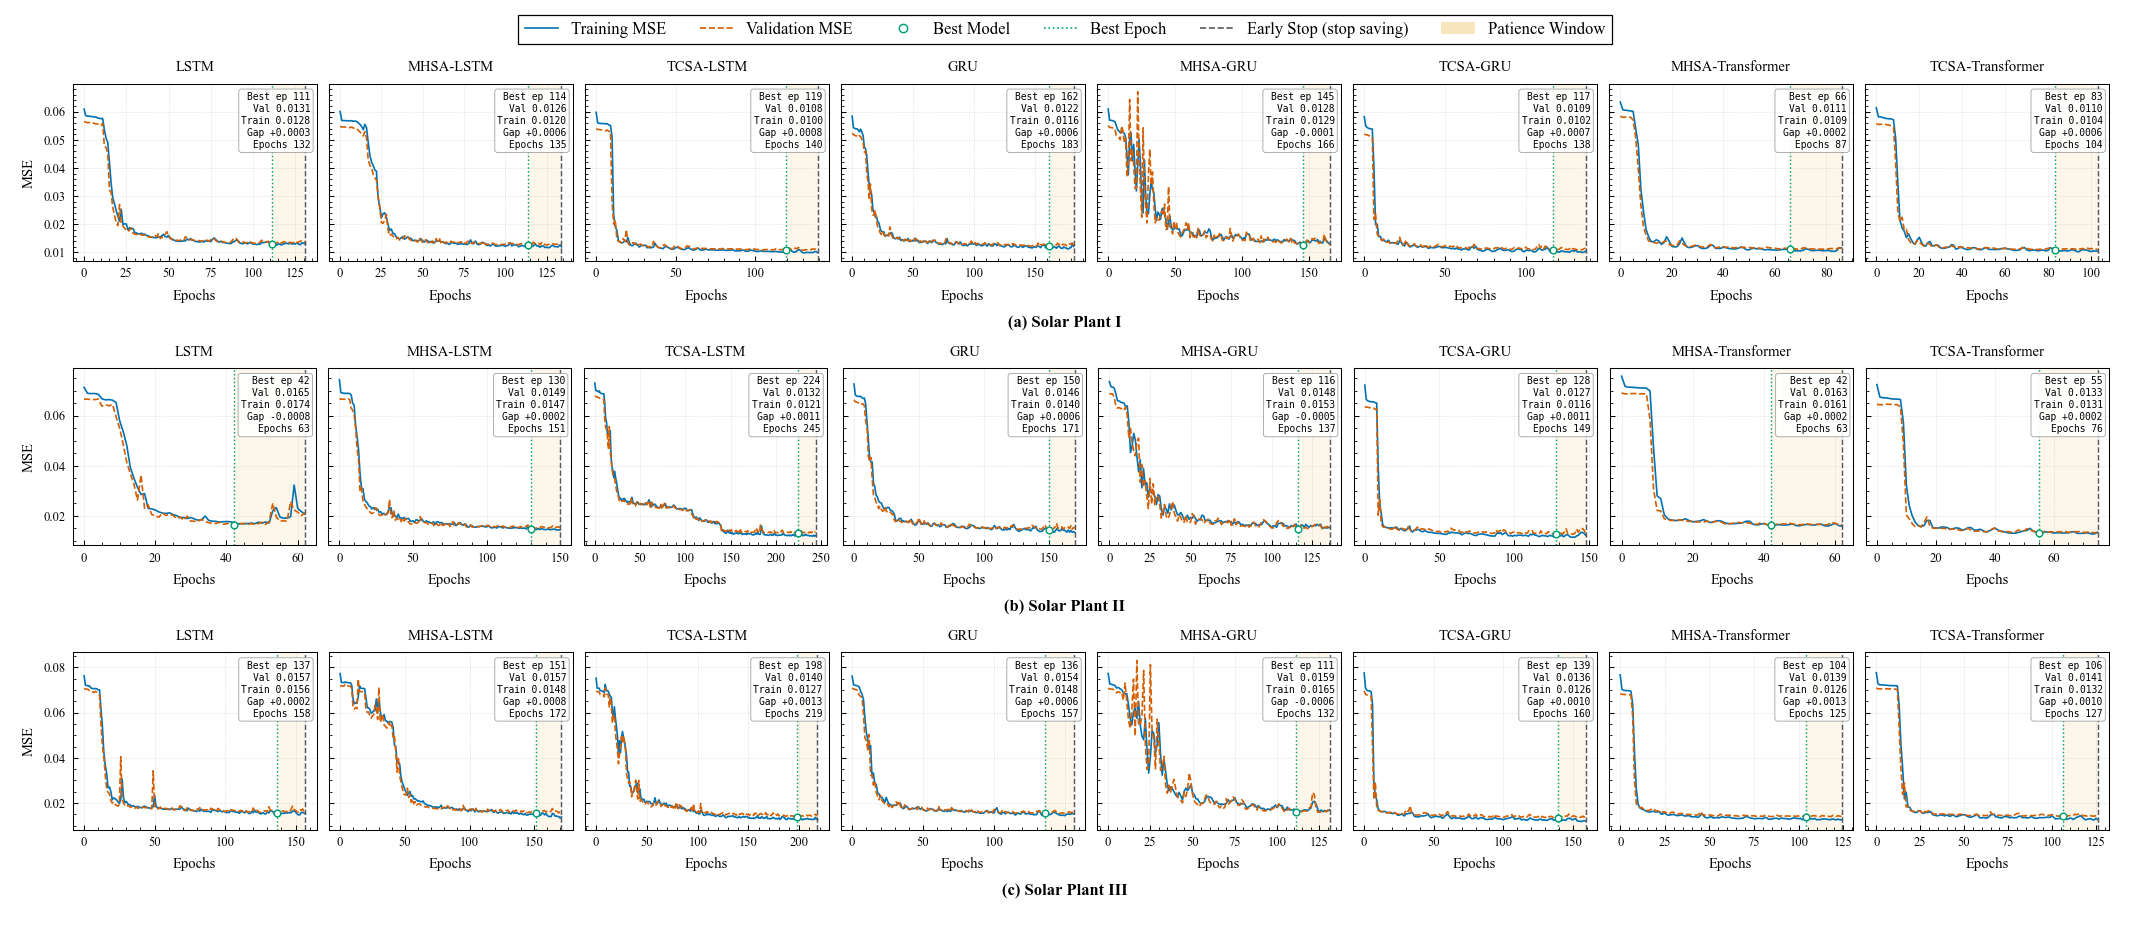

In [561]:
import importlib
importlib.reload(Library.modelDevelopment)
importlib.reload(Library.modelEvaluation)

from Library.modelEvaluation import plot_learning_curves_grid

fig = plot_learning_curves_grid(
        history_dir='../Export/History/Site-02/',
        save_dir='../Export/Figure/Site-02/',
        figsize = (14, 6),
        location='Gyeongju',
        patience=20,
        save_fig=True,
        show_title=False,
    )

# <u>Getting __Datasets__</u>

In [562]:
# ---------- Testing Data ----------
PV1_test = pd.read_csv(f"{impDataDir}Site_02_PV1_Scaled_Test.csv", index_col=0, parse_dates=True)
PV2_test = pd.read_csv(f"{impDataDir}Site_02_PV2_Scaled_Test.csv", index_col=0, parse_dates=True)
PV3_test = pd.read_csv(f"{impDataDir}Site_02_PV3_Scaled_Test.csv", index_col=0, parse_dates=True)

In [563]:
PV1_test

,P_kW,T_env_C,H_env_%,V_wind_m/s,P_rain_mm/h,D_env_g/m^3,P_atm_hPa
DT,,,,,,,
2026-06-01 00:00:00,0.000000,0.606219,0.748947,0.006757,0.000000,0.652074,0.739620
2026-06-01 01:00:00,0.000000,0.600492,0.767148,0.006745,0.000000,0.651681,0.738206
2026-06-01 02:00:00,0.000000,0.580957,0.813595,0.008877,0.000000,0.650433,0.736246
2026-06-01 03:00:00,0.000000,0.574594,0.827451,0.008645,0.000151,0.650061,0.732131
2026-06-01 04:00:00,0.000123,0.567339,0.841426,0.005844,0.000460,0.649808,0.732891
...,...,...,...,...,...,...,...
2026-06-13 20:00:00,0.000000,0.665870,0.849068,0.006318,0.000000,0.738152,0.738075
2026-06-13 21:00:00,0.000000,0.647115,0.890951,0.003871,0.000000,0.743727,0.742529
2026-06-13 22:00:00,0.000000,0.617138,0.954427,0.001033,0.000000,0.743902,0.748692


In [564]:
from Library.modelDevelopment import make_windows

PV1_X_test, PV1_y_test = make_windows(PV1_test, input_len=168, output_len=24, stride=1)
PV2_X_test, PV2_y_test = make_windows(PV2_test, input_len=168, output_len=24, stride=1)
PV3_X_test, PV3_y_test = make_windows(PV3_test, input_len=168, output_len=24, stride=1)


print('='*50)
print("Testing Set Shapes for Solar Plant 1:")
print('-'*50)
print(f'X shape: {PV1_X_test.shape}')
print(f'y shape: {PV1_y_test.shape}')
print('-'*50)
print(f'X shape: {PV2_X_test.shape}')
print(f'y shape: {PV2_y_test.shape}')
print('-'*50)
print(f'X shape: {PV3_X_test.shape}')
print(f'y shape: {PV3_y_test.shape}')
print('='*50)

Testing Set Shapes for Solar Plant 1:
--------------------------------------------------
X shape: (122, 168, 7)
y shape: (122, 24)
--------------------------------------------------
X shape: (122, 168, 7)
y shape: (122, 24)
--------------------------------------------------
X shape: (122, 168, 7)
y shape: (122, 24)


In [565]:
# LSTMs
SolarPlant_1_model_LSTM_baseline  = load_model(expModelDir + 'PV1_model_LSTM.h5')
SolarPlant_1_model_LSTM_typical   = load_model(expModelDir + 'PV1_model_MHSA_LSTM.h5')
SolarPlant_1_model_LSTM_proposed  = load_model(expModelDir + 'PV1_model_TCSA_LSTM.h5')
SolarPlant_2_model_LSTM_baseline  = load_model(expModelDir + 'PV2_model_LSTM.h5')
SolarPlant_2_model_LSTM_typical   = load_model(expModelDir + 'PV2_model_MHSA_LSTM.h5')
SolarPlant_2_model_LSTM_proposed  = load_model(expModelDir + 'PV2_model_TCSA_LSTM.h5')
SolarPlant_3_model_LSTM_baseline  = load_model(expModelDir + 'PV3_model_LSTM.h5')
SolarPlant_3_model_LSTM_typical   = load_model(expModelDir + 'PV3_model_MHSA_LSTM.h5')
SolarPlant_3_model_LSTM_proposed  = load_model(expModelDir + 'PV3_model_TCSA_LSTM.h5')

# GRUs
SolarPlant_1_model_GRU_baseline  = load_model(expModelDir + 'PV1_model_GRU.h5')
SolarPlant_1_model_GRU_typical   = load_model(expModelDir + 'PV1_model_MHSA_GRU.h5')
SolarPlant_1_model_GRU_proposed  = load_model(expModelDir + 'PV1_model_TCSA_GRU.h5')
SolarPlant_2_model_GRU_baseline  = load_model(expModelDir + 'PV2_model_GRU.h5')
SolarPlant_2_model_GRU_typical   = load_model(expModelDir + 'PV2_model_MHSA_GRU.h5')
SolarPlant_2_model_GRU_proposed  = load_model(expModelDir + 'PV2_model_TCSA_GRU.h5')
SolarPlant_3_model_GRU_baseline  = load_model(expModelDir + 'PV3_model_GRU.h5')
SolarPlant_3_model_GRU_typical   = load_model(expModelDir + 'PV3_model_MHSA_GRU.h5')
SolarPlant_3_model_GRU_proposed  = load_model(expModelDir + 'PV3_model_TCSA_GRU.h5')    


# Transformers
# ----- Positional Encoding Layer (fixed sinusoidal) -----
class PositionalEncoding(tf.keras.layers.Layer):        # adds timestep order to embeddings
    def __init__(self, seq_len=168, d_model=32, **kwargs):
        super().__init__(**kwargs)
        pos   = np.arange(seq_len)[:, None]
        i     = np.arange(d_model)[None, :]
        angle = pos / np.power(10000, (2 * (i // 2)) / np.float32(d_model))
        pe              = np.zeros((seq_len, d_model), dtype=np.float32)
        pe[:, 0::2]     = np.sin(angle[:, 0::2])
        pe[:, 1::2]     = np.cos(angle[:, 1::2])
        self.pe         = tf.constant(pe[None, ...])    # (1, seq_len, d_model)
    def call(self, x):
        return x + self.pe                              # inject positions
    def get_config(self):
        return super().get_config()

SolarPlant_1_model_Transformer_typical  = load_model(expModelDir + 'PV1_model_MHSA_Transformer.h5', custom_objects={'PositionalEncoding': PositionalEncoding})
SolarPlant_1_model_Transformer_proposed = load_model(expModelDir + 'PV1_model_TCSA_Transformer.h5', custom_objects={'PositionalEncoding': PositionalEncoding})
SolarPlant_2_model_Transformer_typical  = load_model(expModelDir + 'PV2_model_MHSA_Transformer.h5', custom_objects={'PositionalEncoding': PositionalEncoding})
SolarPlant_2_model_Transformer_proposed = load_model(expModelDir + 'PV2_model_TCSA_Transformer.h5', custom_objects={'PositionalEncoding': PositionalEncoding})
SolarPlant_3_model_Transformer_typical  = load_model(expModelDir + 'PV3_model_MHSA_Transformer.h5', custom_objects={'PositionalEncoding': PositionalEncoding})
SolarPlant_3_model_Transformer_proposed = load_model(expModelDir + 'PV3_model_TCSA_Transformer.h5', custom_objects={'PositionalEncoding': PositionalEncoding})


# Load the scalers for inverse transforming the predictions
import joblib
SolarPlants_scaler = joblib.load(expModelDir + 'scaler_Site_02.joblib')

In [566]:
# from Library.modelDevelopment import evaluate_model
# E, P = evaluate_model('SP-1-Transformer-Typical', SolarPlant_1_model_Transformer_typical, SolarPlants_scaler, PV1_X_test, PV1_y_test)
# print(P)

Available non-overlapping forecast days: 6 (showing days 2-6).
Saved: ../Export/Figure/Site-02/PredictionComparison-PkW-AllPlants.pdf
Saved: ../Export/Figure/Site-02/PredictionComparison-PkW-AllPlants.png

MAE (kW) on full test set:
Plant |             LSTM |        MHSA-LSTM |        TCSA-LSTM |              GRU |         MHSA-GRU |         TCSA-GRU | MHSA-Transformer | TCSA-Transformer
    1 |            5.942 |            5.794 |            4.743 |            5.553 |            5.507 |            5.077 |            5.741 |            5.616
    2 |            6.953 |            6.426 |            4.964 |            6.309 |            5.647 |            5.236 |            6.416 |            5.893
    3 |            6.676 |            6.128 |            5.323 |            6.180 |            5.903 |            5.510 |            5.730 |            5.618

RMSE (kW) on full test set:
Plant |             LSTM |        MHSA-LSTM |        TCSA-LSTM |              GRU |         MHSA-GRU |    

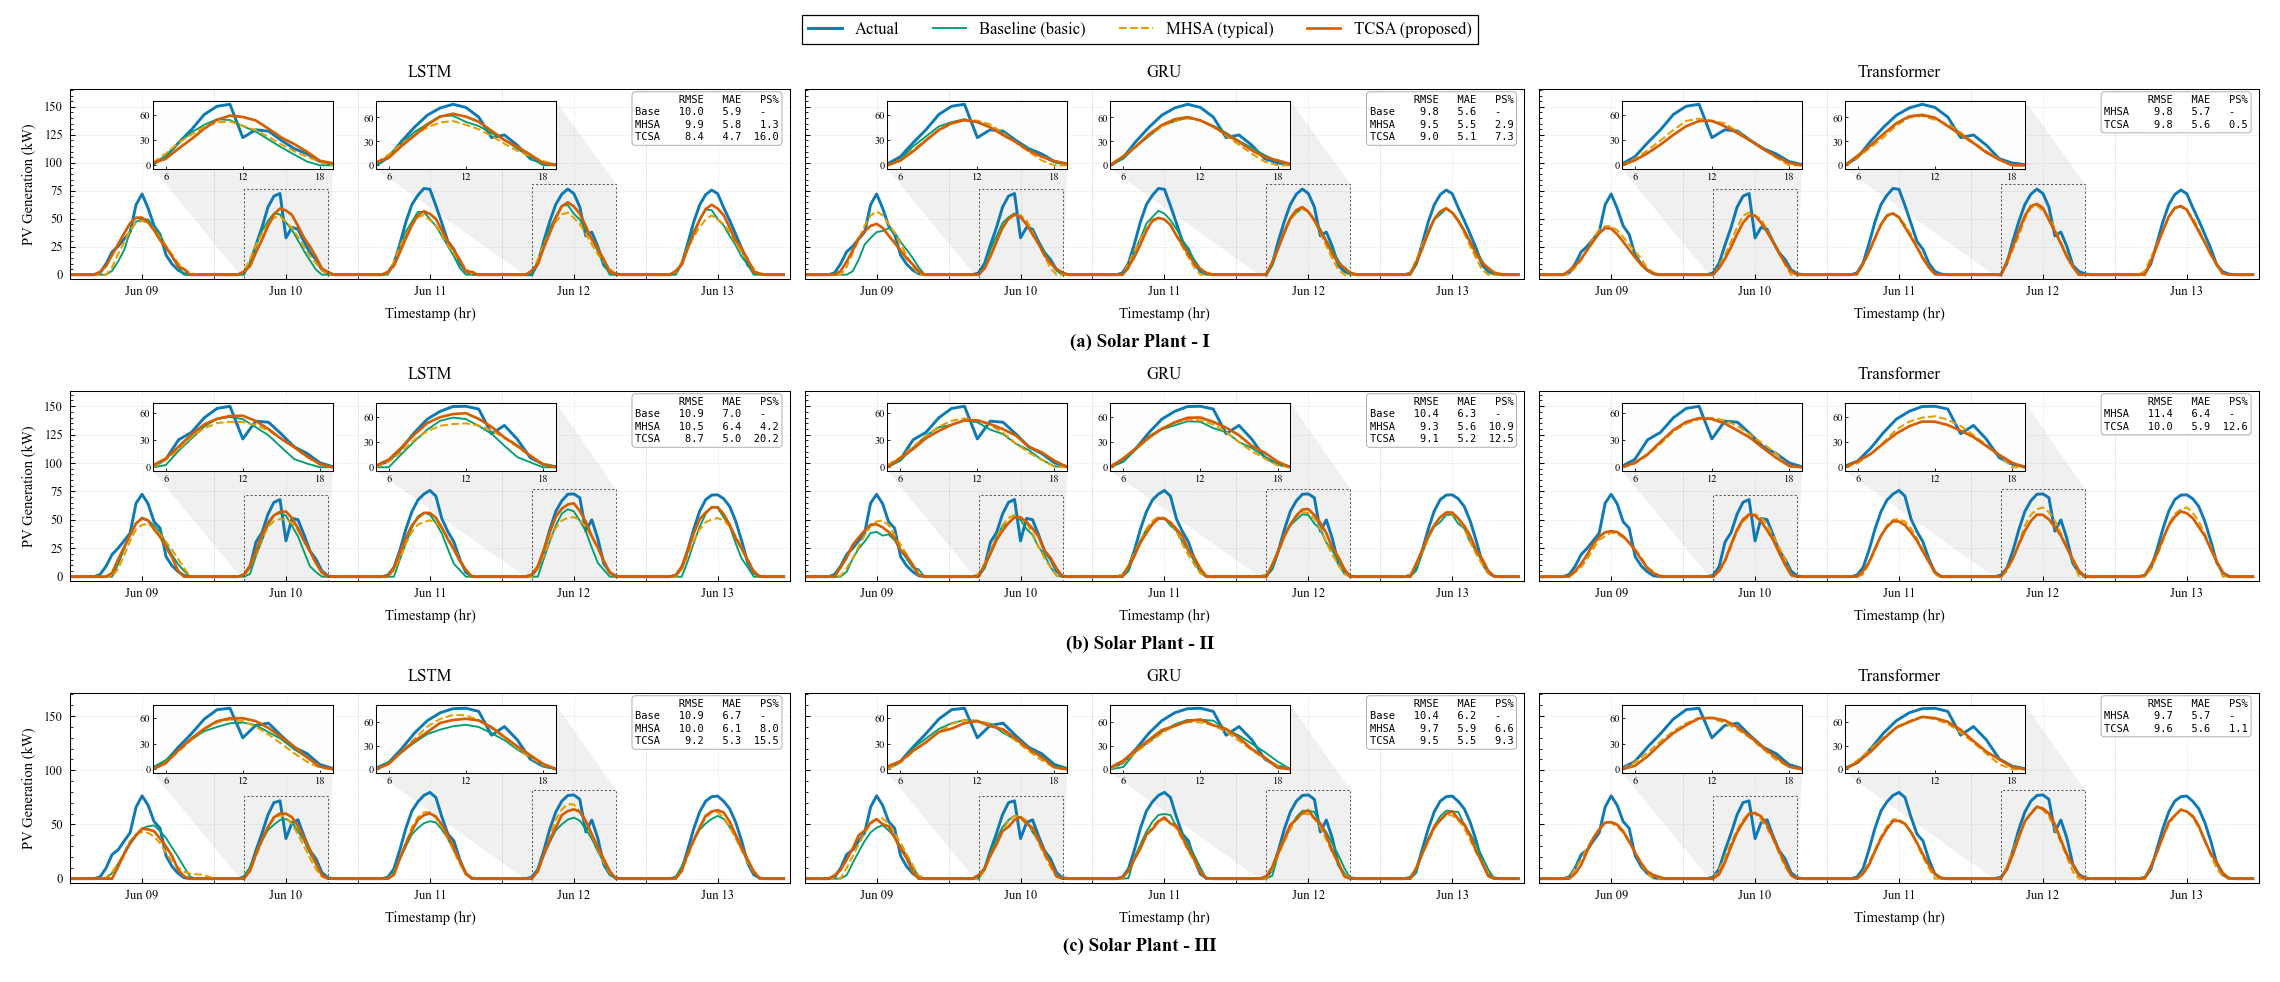

In [567]:
from Library.modelEvaluation import plot_prediction_comparison

models_by_plant = {
    1: {'LSTM': SolarPlant_1_model_LSTM_baseline,
        'MHSA-LSTM': SolarPlant_1_model_LSTM_typical,
        'TCSA-LSTM': SolarPlant_1_model_LSTM_proposed,
        'GRU': SolarPlant_1_model_GRU_baseline,
        'MHSA-GRU': SolarPlant_1_model_GRU_typical,
        'TCSA-GRU': SolarPlant_1_model_GRU_proposed,
        'MHSA-Transformer': SolarPlant_1_model_Transformer_typical,
        'TCSA-Transformer': SolarPlant_1_model_Transformer_proposed},
    2: {'LSTM': SolarPlant_2_model_LSTM_baseline,
        'MHSA-LSTM': SolarPlant_2_model_LSTM_typical,
        'TCSA-LSTM': SolarPlant_2_model_LSTM_proposed,
        'GRU': SolarPlant_2_model_GRU_baseline,
        'MHSA-GRU': SolarPlant_2_model_GRU_typical,
        'TCSA-GRU': SolarPlant_2_model_GRU_proposed,
        'MHSA-Transformer': SolarPlant_2_model_Transformer_typical,
        'TCSA-Transformer': SolarPlant_2_model_Transformer_proposed},
    3: {'LSTM': SolarPlant_3_model_LSTM_baseline,
        'MHSA-LSTM': SolarPlant_3_model_LSTM_typical,
        'TCSA-LSTM': SolarPlant_3_model_LSTM_proposed,
        'GRU': SolarPlant_3_model_GRU_baseline,
        'MHSA-GRU': SolarPlant_3_model_GRU_typical,
        'TCSA-GRU': SolarPlant_3_model_GRU_proposed,
        'MHSA-Transformer': SolarPlant_3_model_Transformer_typical,
        'TCSA-Transformer': SolarPlant_3_model_Transformer_proposed},
}

X_by_plant = {1: PV1_X_test, 2: PV2_X_test, 3: PV3_X_test}
y_by_plant = {1: PV1_y_test, 2: PV2_y_test, 3: PV3_y_test}

index_by_plant = {1: PV1_test.index, 2: PV2_test.index, 3: PV3_test.index}

fig, met = plot_prediction_comparison(
    models_by_plant, X_by_plant, y_by_plant,
    scaler=SolarPlants_scaler, target_idx=0, output_len=24,
    figsize = (15, 6.4),
    layout='family',
    days=(2, 6),
    xunit='day',                  # mode: 'day' (dates/day-numbers) or 'hour'
    xlabel='Timestamp (hr)',      # <-- the axis TEXT goes here
    index_by_plant=index_by_plant,
    input_len=168,
    show_title=False,
)

Saved: ../Export/Figure/Site-02/MetricSummary-PkW-AllPlants.pdf
Saved: ../Export/Figure/Site-02/MetricSummary-PkW-AllPlants.png

TCSA improvement vs family reference (error metrics: % reduction; R2: +pp):
Metric | P1-L | P1-G | P1-T | P2-L | P2-G | P2-T | P3-L | P3-G | P3-T
   MAE |  20.2 |   8.6 |   2.2 |  28.6 |  17.0 |   8.2 |  20.3 |  10.8 |   2.0
  RMSE |  16.0 |   7.3 |   0.5 |  20.2 |  12.5 |  12.6 |  15.5 |   9.3 |   1.1
 rRMSE |  16.0 |   7.3 |   0.5 |  20.2 |  12.5 |  12.6 |  15.5 |   9.3 |   1.1
    R2 |   4.7 |   2.1 |   0.1 |   6.9 |   4.0 |   4.9 |   4.8 |   2.7 |   0.3
Average rRMSE reduction, LSTM family: 17.2%
Average rRMSE reduction, GRU family: 9.7%
Average rRMSE reduction, Transformer family: 4.7%
Saved: ../Export/Data/Site-02/MetricSummary-PkW-AllPlants-TCSA-Improvement.csv
Saved: ../Sim/Site-02/AllPlants-TCSA-Improvement.csv


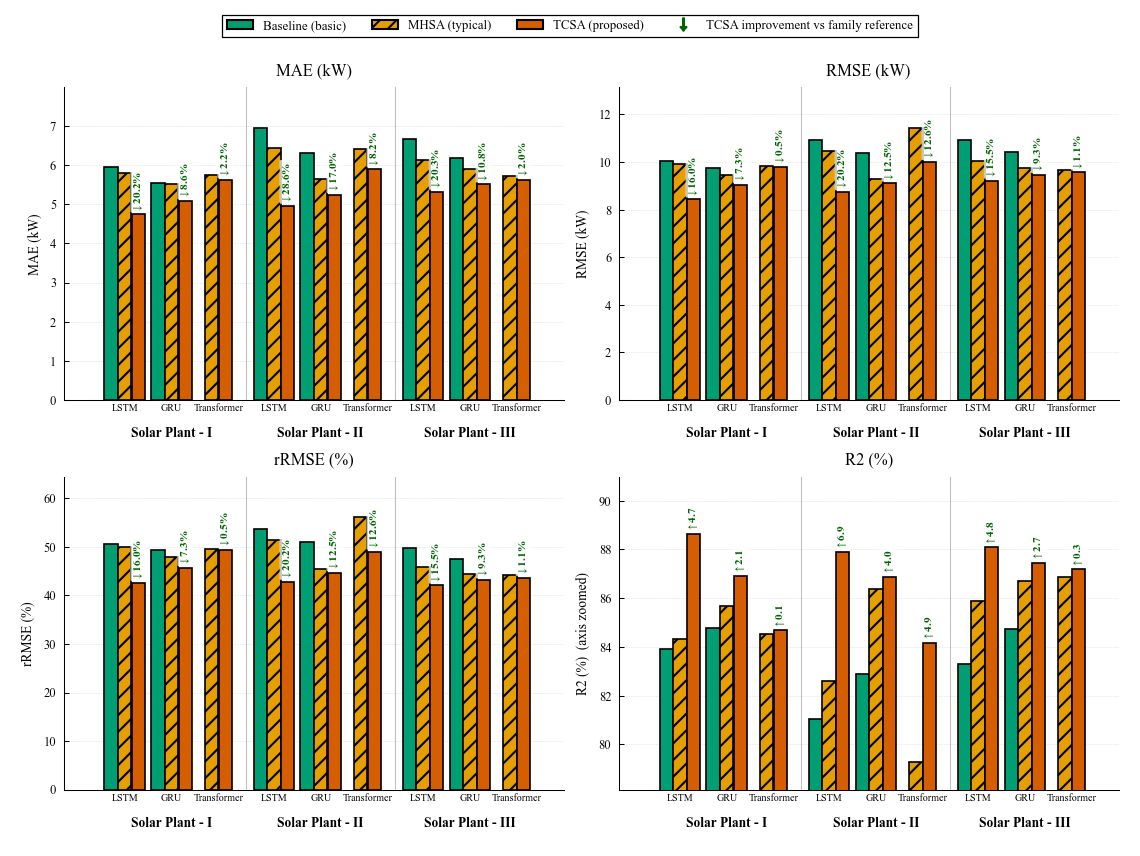

In [568]:
import importlib
importlib.reload(Library.modelDevelopment)
importlib.reload(Library.modelEvaluation)

from Library.modelEvaluation import plot_metric_summary

# after plot_prediction_comparison:
fig2, imp = plot_metric_summary(metrics=met, figsize=(7.4, 5.6), show_title=False)

# # or offline, no models/data needed:
# fig2, imp = plot_metric_summary(
#     csv_path='../Export/Data/Site-02/PredictionComparison-PkW-AllPlants-Metrics.csv')

In [569]:
"""
generate_prediction_csvs.py
===========================================================================
Exports one CSV per solar plant containing the ACTUAL PV generation and the
predictions of all 8 models, aligned to timestamps and in real units (kW).

Output (in ../Sim/{Site_Info}/ by default):
    SolarPlant1_Predictions.csv
    SolarPlant2_Predictions.csv
    SolarPlant3_Predictions.csv

Each file has columns:
    Timestamp, Actual_kW,
    LSTM_kW, MHSA_LSTM_kW, TCSA_LSTM_kW,
    GRU_kW,  MHSA_GRU_kW,  TCSA_GRU_kW,
    MHSA_Transformer_kW, TCSA_Transformer_kW

Pipeline (mirrors Site02_ResultAnalysis.ipynb / plot_prediction_comparison):
  1. windowed test set  : input_len=168 (7-day history) -> output_len=24 (24-h forecast)
  2. model.predict on X : scaled predictions, shape (n_windows, 24)
  3. inverse-transform  : back to kW using the MinMaxScaler (target column idx 0)
  4. reconstruct series : take NON-OVERLAPPING 24-h forecast blocks and concatenate,
                          so the exported horizon is continuous and gap-free
                          (this is the same day-by-day horizon the plot draws).

Run this as an extra cell/script AFTER the notebook has already built:
    models_by_plant, X_by_plant, y_by_plant, index_by_plant, SolarPlants_scaler
(everything up to and including the model-loading cell in the notebook).
===========================================================================
"""

import os
import numpy as np
import pandas as pd

# ----------------------------------------------------------------------------
# Config — must match the notebook
# ----------------------------------------------------------------------------
INPUT_LEN   = 168          # hours of history per window
OUTPUT_LEN  = 24           # hours forecast per window
TARGET_IDX  = 0            # P_kW is the first column of the scaled feature set
Site_Info   = 'Site-02'
OUT_DIR     = f'../Sim/{Site_Info}/'
# NOTE: the number of features is taken from the fitted scaler at runtime
# (scaler_Site_02 was fit on 9 columns, even though the test frames expose 7).

# Column order for the exported CSVs (keys must exist in models_by_plant[plant])
MODEL_ORDER = [
    ('LSTM',             'LSTM_kW'),
    ('MHSA-LSTM',        'MHSA_LSTM_kW'),
    ('TCSA-LSTM',        'TCSA_LSTM_kW'),
    ('GRU',              'GRU_kW'),
    ('MHSA-GRU',         'MHSA_GRU_kW'),
    ('TCSA-GRU',         'TCSA_GRU_kW'),
    ('MHSA-Transformer', 'MHSA_Transformer_kW'),
    ('TCSA-Transformer', 'TCSA_Transformer_kW'),
]


# ----------------------------------------------------------------------------
# Helpers
# ----------------------------------------------------------------------------
def inverse_target(scaler, arr):
    """Inverse-transform ONLY the target column of the MinMaxScaler.
    The scaler's own feature count is used so the dummy always broadcasts,
    regardless of how many columns it was fit on (P_kW must be at index 0).
    `arr` may be any shape; the original shape is preserved."""
    n_features = getattr(scaler, 'n_features_in_', None)
    if n_features is None:                       # older sklearn fallback
        n_features = len(np.atleast_1d(scaler.scale_))
    arr = np.asarray(arr, dtype=float)
    flat = arr.reshape(-1)
    dummy = np.zeros((flat.size, n_features), dtype=float)
    dummy[:, TARGET_IDX] = flat
    inv = scaler.inverse_transform(dummy)[:, TARGET_IDX]
    return inv.reshape(arr.shape)


def nonoverlapping_block_starts(n_windows, output_len):
    """Window indices whose 24-h forecasts tile the horizon without overlap:
    0, 24, 48, ...  (stride == output_len)."""
    return list(range(0, n_windows, output_len))


def forecast_timestamps(index, input_len, start_win, output_len):
    """Timestamps that window `start_win` forecasts.
    Window i predicts rows [i+input_len : i+input_len+output_len)."""
    a = start_win + input_len
    b = a + output_len
    return index[a:b]


def build_plant_frame(plant, models_by_plant, X_by_plant, y_by_plant,
                      index_by_plant, scaler):
    """Assemble the continuous Actual + 8-model prediction DataFrame for one plant."""
    X       = X_by_plant[plant]
    y_true  = y_by_plant[plant]                 # (n_windows, 24) scaled
    index   = index_by_plant[plant]
    n_win   = X.shape[0]
    starts  = nonoverlapping_block_starts(n_win, OUTPUT_LEN)

    # ---- timestamps + actual (concatenated non-overlapping blocks) ----
    ts_list, actual_list = [], []
    for s in starts:
        ts = forecast_timestamps(index, INPUT_LEN, s, OUTPUT_LEN)
        if len(ts) < OUTPUT_LEN:                # drop a trailing partial block
            continue
        ts_list.append(pd.DatetimeIndex(ts))
        actual_list.append(inverse_target(scaler, y_true[s]))     # (24,)
    timestamps = pd.DatetimeIndex(np.concatenate([t.values for t in ts_list]))
    actual_kw  = np.concatenate(actual_list)

    frame = pd.DataFrame({'Timestamp': timestamps, 'Actual_kW': actual_kw})

    # ---- per-model predictions over the same blocks ----
    valid_starts = [s for s in starts
                    if len(forecast_timestamps(index, INPUT_LEN, s, OUTPUT_LEN)) == OUTPUT_LEN]

    for model_key, col_name in MODEL_ORDER:
        model = models_by_plant[plant].get(model_key)
        if model is None:
            print(f"  [plant {plant}] WARNING: model '{model_key}' missing -> NaN column")
            frame[col_name] = np.nan
            continue
        preds_scaled = model.predict(X, verbose=0)          # (n_windows, 24) scaled
        blocks = [inverse_target(scaler, preds_scaled[s]) for s in valid_starts]
        frame[col_name] = np.concatenate(blocks)

    # clip tiny negative artefacts from inverse-transform (PV can't be < 0)
    num_cols = [c for c in frame.columns if c != 'Timestamp']
    frame[num_cols] = frame[num_cols].clip(lower=0).round(4)
    return frame


# ----------------------------------------------------------------------------
# Main
# ----------------------------------------------------------------------------
def main(models_by_plant, X_by_plant, y_by_plant, index_by_plant, scaler,
         out_dir=OUT_DIR):
    os.makedirs(out_dir, exist_ok=True)
    for plant in (1, 2, 3):
        print(f"Plant {plant}: generating predictions for 8 models ...")
        df = build_plant_frame(plant, models_by_plant, X_by_plant, y_by_plant,
                               index_by_plant, scaler)
        path = os.path.join(out_dir, f"SolarPlant{plant}_Predictions.csv")
        df.to_csv(path, index=False)
        print(f"  saved {path}  ({len(df)} rows, {df.shape[1]} cols)")
    print("Done.")


# When pasted as a notebook cell (after the model-loading cell), just call:
if __name__ == '__main__' or 'models_by_plant' in globals():
    main(models_by_plant, X_by_plant, y_by_plant, index_by_plant, SolarPlants_scaler)

Plant 1: generating predictions for 8 models ...
  saved ../Sim/Site-02/SolarPlant1_Predictions.csv  (144 rows, 10 cols)
Plant 2: generating predictions for 8 models ...
  saved ../Sim/Site-02/SolarPlant2_Predictions.csv  (144 rows, 10 cols)
Plant 3: generating predictions for 8 models ...
  saved ../Sim/Site-02/SolarPlant3_Predictions.csv  (144 rows, 10 cols)
Done.
